In [12]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
# -----------------------------------------------------------------
# SETUP (given)
# -----------------------------------------------------------------
# df = pd.read_csv('cleaned_boston.csv')
# train_df = df[df['split'] == 'train'].drop(columns=['split'])
# test_df  = df[df['split'] == 'test'].drop(columns=['split'])

# X_train = train_df.drop(columns=['attack'])
# y_train = train_df['attack']
# X_test  = test_df.drop(columns=['attack'])
# y_test  = test_df['attack']

X, y = make_classification(
    n_samples=2000, n_features=25, n_informative=15, n_redundant=5,
    weights=[0.85, 0.15], random_state=42
)
X = pd.DataFrame(X, columns=[f"network_feature_{i}" for i in range(25)])
y = pd.Series(y, name="target")
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
X_train.shape
X_test.shape

X_train.isnull().sum().sum()
y_train.value_counts()#check how many belong to each classification
#The dataset is unbalanced

target
0    1356
1     244
Name: count, dtype: int64

In [15]:
ss = StandardScaler()
X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)
#I'm not sure what would go wrong if I scaled on the entire X instead of X_train

In [16]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_ss)
X_test_pca = pca.transform(X_test_ss)

print(X_train_ss.shape[1]) #NUmber of features is essentially the second column in shape
print(X_train_pca.shape[1])
print(pca.explained_variance_ratio_.sum())
#A high variance ratio doesn't guarantee accuracy by itself. you need other things like precision and recall

25
17
0.9512064337302366


Accuracy: 0.8925
Precision: 1.0
Recall: 0.29508196721311475
Confusion Matrix:
 [[339   0]
 [ 43  18]]


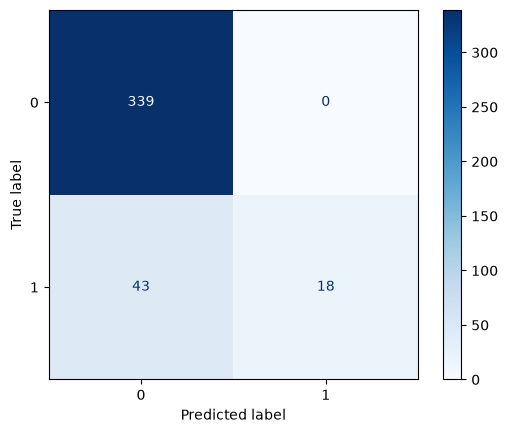

In [33]:
rf = RandomForestClassifier(n_estimators = 150, max_depth = 10, random_state = 42)
rf.fit(X_train_ss,y_train)

y_pred = rf.predict(X_test_ss)
cm = confusion_matrix(y_test, y_pred)

rf_acc = accuracy_score(y_test, y_pred)
rf_prec = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n",cm )


ConfusionMatrixDisplay(cm, display_labels=rf.classes_).plot(cmap="Blues")

In [18]:
feat = pd.Series(rf.feature_importances_, index = X.columns)
feat.sort_values(ascending = False).head(5)

network_feature_3     0.095507
network_feature_4     0.073484
network_feature_9     0.064666
network_feature_0     0.056954
network_feature_24    0.056772
dtype: float64

Accuracy: 0.88
Precision: 0.8095238095238095
Recall: 0.2786885245901639
Confusion Matrix:
 [[335   4]
 [ 44  17]]


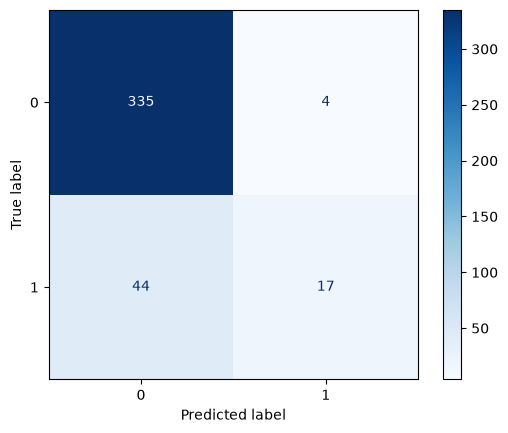

In [35]:
rf2 = RandomForestClassifier(n_estimators = 150, max_depth = 10, random_state = 42)
rf2.fit(X_train_pca,y_train)

y_pred = rf2.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred)

rf2_acc = accuracy_score(y_test, y_pred)
rf2_prec = precision_score(y_test, y_pred)
rf2_recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))    
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n",cm )

ConfusionMatrixDisplay(cm, display_labels=rf2.classes_).plot(cmap="Blues")

In [31]:
model = tf.keras.Sequential([
    layers.Dense(64, activation = "relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation = "relu"),
    layers.Dense(1, activation = "sigmoid")
])

model.compile(optimizer="adam",loss = "binary_crossentropy", metrics=["accuracy"])

model.fit(X_train_pca, y_train, epochs=30,batch_size=32, validation_split=0.2, verbose=0)
y_pred = model.predict(X_test_pca).ravel() #what does .ravel() do?
y_pred = (y_pred >= 0.5).astype(int)
y_pred

model_acc = accuracy_score(y_test,y_pred)
model_prec = precision_score(y_test,y_pred)
model_recall = recall_score(y_test,y_pred)

print("Accuracy:", model_acc)
print("Precision:", model_prec)    
print("Recall:", model_recall)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 0.91
Precision: 0.8787878787878788
Recall: 0.47540983606557374


In [37]:
comp = pd.DataFrame({
    "RF":[rf_acc,rf_prec,rf_recall],
    "RF_PCA":[rf2_acc,rf2_prec,rf2_recall],
    "ANN":[model_acc,model_prec,model_recall]
}, index=["accuracy_score","precision_score","recall_score"])

comp

,RF,RF_PCA,ANN
accuracy_score,0.892500,0.880000,0.910000
precision_score,1.000000,0.809524,0.878788
recall_score,0.295082,0.278689,0.475410
